In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "red_wine_quality_dataset" / "winequality-red.csv"
df = pd.read_csv(train_path)

In [3]:
X = df.drop(columns="quality")
y = df["quality"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42
)

models = {
    "random_forest": RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}

In [4]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    results[name] = pred
    print(name)
    print(" MAE:", round(mean_absolute_error(y_valid, pred), 3))
    print(" RMSE:", round(np.sqrt(mean_squared_error(y_valid, pred)), 3))

random_forest
 MAE: 0.432
 RMSE: 0.565
gradient_boosting
 MAE: 0.476
 RMSE: 0.597


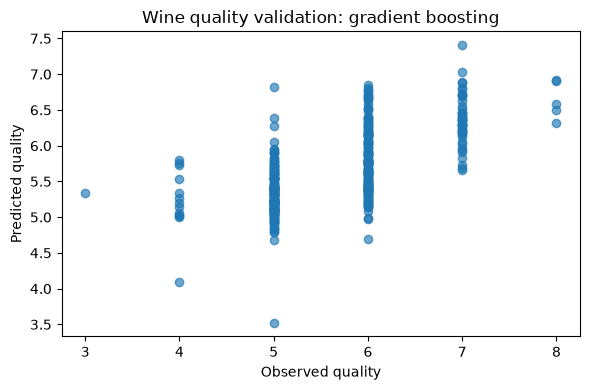

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(y_valid, results["gradient_boosting"], alpha=0.65)
plt.xlabel("Observed quality")
plt.ylabel("Predicted quality")
plt.title("Wine quality validation: gradient boosting")
plt.tight_layout()
plt.show()